###Project Overview: Advanced Time-Series Forecasting for Daily Sales

This analysis explores a comprehensive time-series forecasting pipeline, transitioning from classical statistical methods to deep learning and tree-based machine learning architectures. The primary objective is to accurately predict daily sales by identifying and mapping complex temporal patterns, weekly seasonality, and non-linear relationships.

The modeling progression follows a systematic approach:

**Statistical Baselines**: Establishing baseline predictions using ARIMA, and advancing to SARIMA and SARIMAX to explicitly handle 7-day seasonality and exogenous calendar variables (weekday and month).

**Deep Learning**: Implementing a Long Short-Term Memory (LSTM) neural network to capture deeper, non-linear sequential dependencies without relying on rigid mathematical assumptions like strict stationarity.

**Supervised Machine Learning**: Transforming the sequential data into a tabular format using advanced feature engineering (lagged variables and rolling windows) to train standard predictive algorithms, specifically Linear Regression and hyperparameter-optimized XGBoost.

**Key Findings Overview**
Throughout the evaluation, the LSTM architecture demonstrated the most robust overall predictive performance, adeptly capturing the complex temporal dynamics of the sales cycle. However, the supervised learning approach (specifically XGBoost) yielded the most significant improvements in the Mean Absolute Percentage Error (MAPE), highlighting the distinct advantages of explicit feature engineering for optimizing percentage-based accuracy.

In [ ]:
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sn
import matplotlib.pyplot as plt

# Time Series
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Scikit-Learn
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [ ]:
df = pd.read_csv('/content/train.csv')

In [ ]:
df.shape

(913000, 4)

In [ ]:
df.head()

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [ ]:
df.isnull().sum()

,0
date,0
store,0
item,0
sales,0


count    913000.000000
mean         52.250287
std          28.801144
min           0.000000
25%          30.000000
50%          47.000000
75%          70.000000
max         231.000000
Name: sales, dtype: float64


<Axes: >

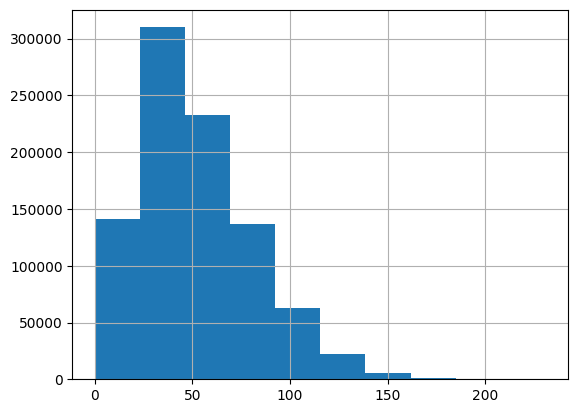

In [ ]:
print(df['sales'].describe())
df['sales'].hist()

#Data Preprocessing
For the purpose of this project, we will only look at the sales of 'item' - 1 from 'store' - 1. The dataset is split into train and test sets, where the train set contains sales record from January 2013 to September 2017 and the test set (validation set) contains sales records of the last three month of 2017.

Some new features have been created from the date field, for the purpose of exploratory data analysis and causal modelling.


In [ ]:
# Filter records for store 1 and item 1 -> to be able to scale to other items in the future
df = df[(df['store'] == 1) & (df['item'] == 1)].copy()

# Convert date column to datetime object (explicit format prevents warnings)
df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d')

# Create Date-related Features to be used for EDA and Supervised ML: Regression
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['weekday'] = df['date'].dt.weekday + 1  # Shifts Monday=0-Sunday=6 to Monday=1-Sunday=7

# Split the series to predict the last 3 months of 2017 using modern indexing
temp_df = df.set_index('date')
train_df = temp_df.loc[:'2017-09-30'].reset_index(drop=False)
test_df = temp_df.loc['2017-10-01':].reset_index(drop=False)

train_df.head()

,date,store,item,sales,year,month,day,weekday
0,2013-01-01,1,1,13,2013,1,1,2
1,2013-01-02,1,1,11,2013,1,2,3
2,2013-01-03,1,1,14,2013,1,3,4
3,2013-01-04,1,1,13,2013,1,4,5
4,2013-01-05,1,1,10,2013,1,5,6


In [ ]:
test_df.head()

,date,store,item,sales,year,month,day,weekday
0,2017-10-01,1,1,21,2017,10,1,7
1,2017-10-02,1,1,12,2017,10,2,1
2,2017-10-03,1,1,18,2017,10,3,2
3,2017-10-04,1,1,15,2017,10,4,3
4,2017-10-05,1,1,20,2017,10,5,4


#EDA
The plots below try to capture the trend and distribution of sales through weeks, months and years.

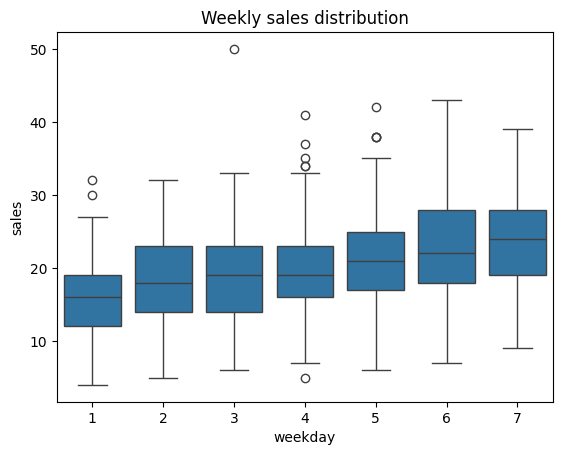

In [ ]:
plot = sn.boxplot(x='weekday', y='sales', data=df)
_ = plot.set(title='Weekly sales distribution')

Inference: The average number of sales increases over the week, is maximum on Saturday (6), and takes a sharp fall on Sunday (7)

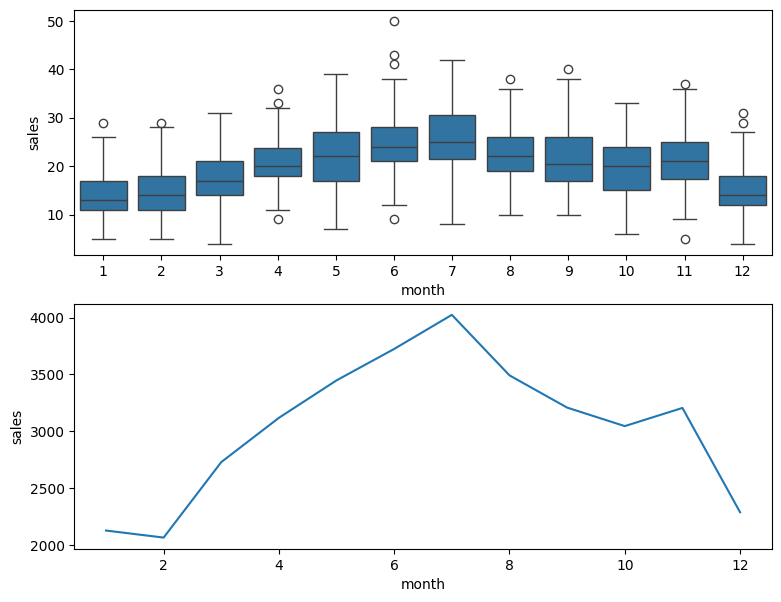

In [ ]:
monthly_agg = df.groupby('month')['sales'].sum().reset_index()
fig, axs = plt.subplots(nrows=2, figsize=(9,7))
sn.boxplot(x='month', y='sales', data=df, ax=axs[0])
_ = sn.lineplot(x='month', y='sales', data=monthly_agg, ax=axs[1])

Inference: From the number of sales vs. year plot, we can infer an increasing trend over the years. The aggregate number of sales has increased from approximately 6000 in 2013 to slightly over 8000 in 2017, i.e. a 33.3% increase in the number of sales approximately. A clear trend is captured by the lineplot above.

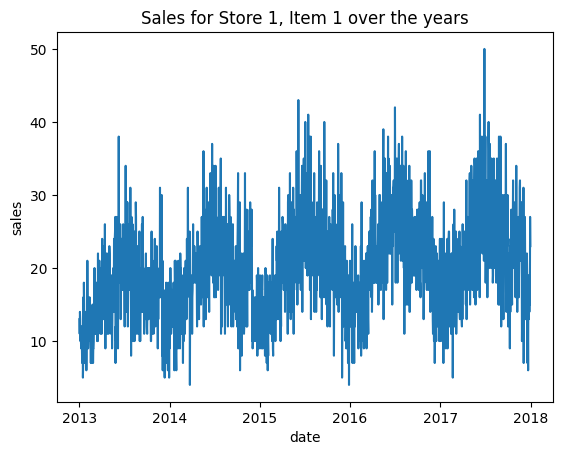

In [ ]:
plot = sn.lineplot(x='date', y='sales', data=df)
_ = plot.set(title='Sales for Store 1, Item 1 over the years')

Inference: There is a seasonal pattern in the number of sales of 'item' - 1 at 'store' - 1. As also infered in the plot for sales vs. month above, we can see an increase in the sales in the first half of the year, peaking in July, and then a gradual decrease till December. This pattern is repeated each year, 2013 onwards.

### Quantitative Methods to Forecast Product Sales

It can be fairly concluded from the data exploratory plots above that there is seasonality present in the product sales data, along with a greneral increase in the number of sales over the years. Therefore, in order to forecast the number of sales for the last three months of 2017, we will keep in mind the linear trend and seasonality present in the product sales. <br>
There are multiple ways to approach the forecasting problem, we can either build traditional time series models, or use causal models, such as linear regression. We will look at both these methods and try to evaluate our forecasts using the validation set.

### 1. Baseline Model: Seasonal Naive

Before we get to the more advanced time-series forecasting methods, let's take a look at a basic method - Seasonal Naive. It can serve as a quick calculation to get a baseline until something better can come along. Or, perhaps there is very little variance in the data, then this method can be good enough.

<b> What is Seasonal Naive? </b>

It is a naive method that takes the seasonal patterns into account by looking at what happened same time last year. For example, if we want to predict the sales during December 2017, the seasonal naive method will assume the same number of sales for December 2017 as was in December 2016. Fortunately, we have at least one-year of sales data, this method might make no sense otherwise. <br>

In the code below, one year is subtracted from the dates in the test data, and one day is added to the resulting difference, after which they are looked up in the training data to return the sales from those respective dates. So keeping the seasonality in mind, we now have our naive forecasts based on the number of sales from a year ago.

In [ ]:
# Subtract 1 year and add 1 day using native Pandas offsets
dates = test_df['date'] - pd.DateOffset(years=1) + pd.Timedelta(days=1)

# Lookup matching sales from the training data safely
seasonal_naive_sales = train_df[train_df['date'].isin(dates)]['sales']

# Make a copy of the test_df and make naive predictions for the last 3 months of 2017
sn_pred_df = test_df.copy().drop('sales', axis=1)
sn_pred_df['seasonal_naive_sales'] = pd.DataFrame(seasonal_naive_sales).set_index(test_df.index)
sn_pred_df.head()

,date,store,item,year,month,day,weekday,seasonal_naive_sales
0,2017-10-01,1,1,2017,10,1,7,26
1,2017-10-02,1,1,2017,10,2,1,20
2,2017-10-03,1,1,2017,10,3,2,28
3,2017-10-04,1,1,2017,10,4,3,17
4,2017-10-05,1,1,2017,10,5,4,22


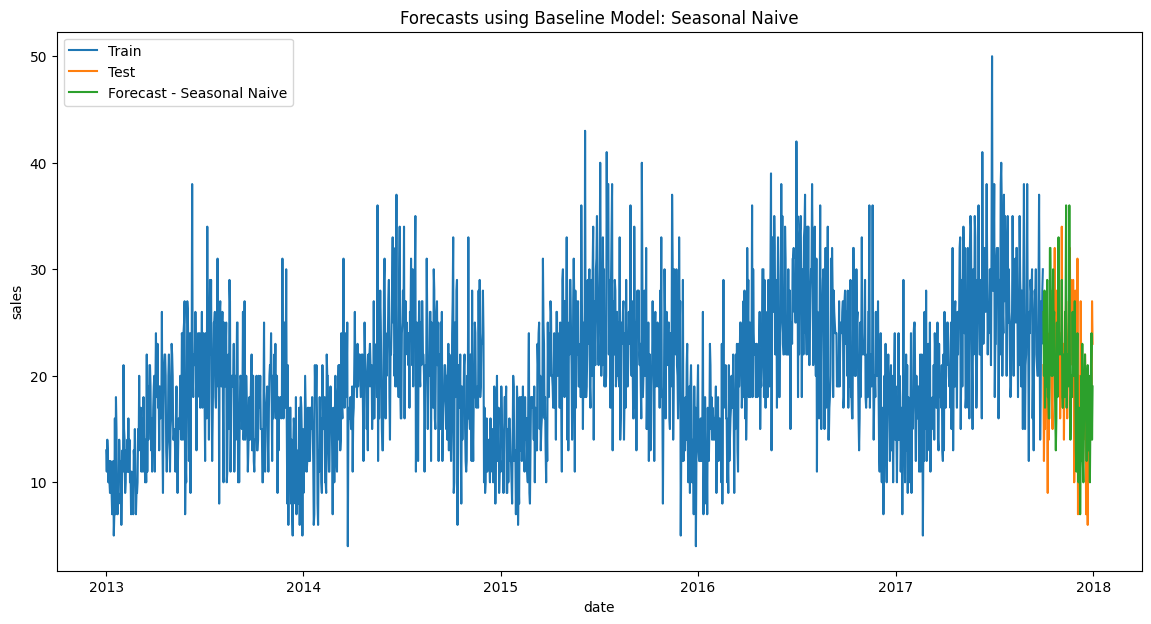

In [ ]:
plt.figure(figsize=(14,7))
plt.plot(train_df['date'], train_df['sales'], label='Train')
plt.plot(test_df['date'], test_df['sales'], label='Test')
plt.plot(sn_pred_df['date'], sn_pred_df['seasonal_naive_sales'], label='Forecast - Seasonal Naive')
plt.legend(loc='best')
plt.xlabel('date')
plt.ylabel('sales')
plt.title('Forecasts using Baseline Model: Seasonal Naive')
plt.show()

Inference: To the naked eye, the forecasts seem alright the decreasing trend is clearly captured by our naive method. However, we will formally quantify the performance using forecast accuracy metrics

<b> Evaluating the Forecasts </b>

There are number of widely accepted forecasting metrics, and the most common metric is <b>forecast error</b>. The error can simply be calculated by finding the diffrence between the actual sales value and the forecasted sales value. For example, if 10 items are sold on a day, and you predicted 14 items to be sold, you have an error of -4.

In order to evaluate the overall forecast, we will look at metrics like <b>mean absolute error</b> (MAE), <b>root mean squared error</b> (RMSE) and a percentage error metric - <b>mean absolute percentage error</b> (MAPE).

+ <b>MAE:</b> It is the absolute value of the error, summed for each observed day, and divided by the total number of observed days.

+ <b>RMSE:</b> It is similar to MAE, however rather than the absolute value, the error is squared before it is summed, and then the square root is taken to normalize the units. Because we take the square of the error, we wind up punishing large forecasting errors more than small ones.

The above two metrics are scale-dependent meaning that we cannot use them to compare forecasts on different scales. MAPE on the other hand is a scale-independent metric.

+ <b>MAPE:</b> It can be used for meaningful comparisions, it is calculated by dividing the sum of absolute errors by sum of actual sales to get a percentage indicator that is scaled to the actual sales.

Let's apply the above metrics to our forecasts and see how they compare.

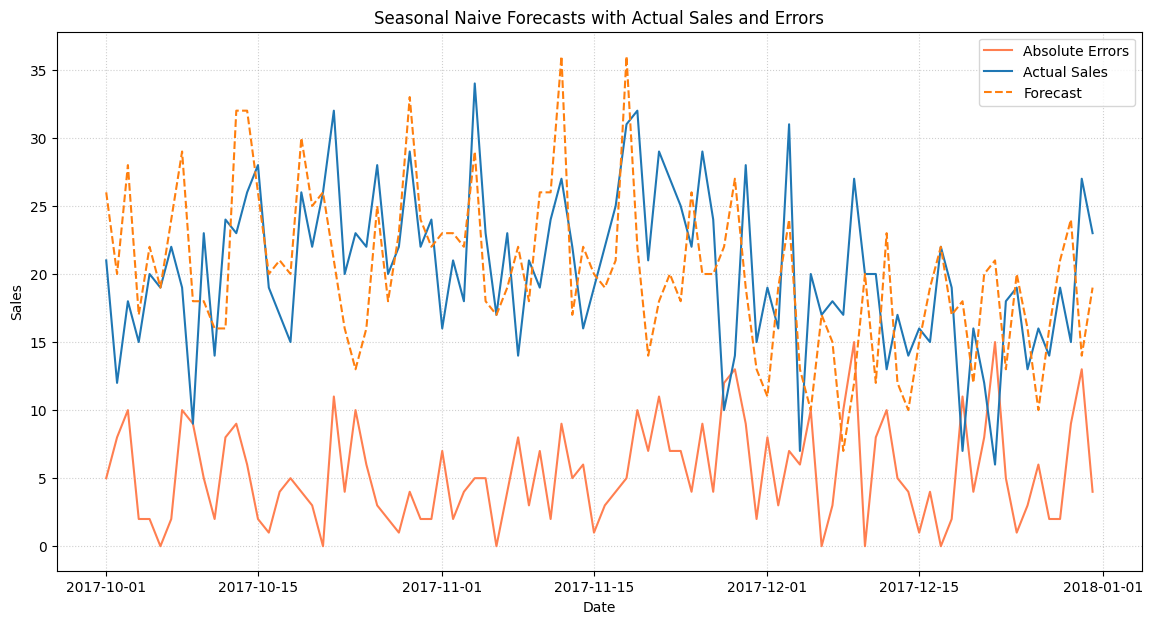

,total_sales,total_sn_pred_sales,overall_error,MAE,RMSE,MAPE
model,,,,,,
Seasonal Naive,1861,1851,10,5.391304,6.507521,31.794044


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Extract actuals and predictions as clean arrays
actuals = test_df['sales']
preds = sn_pred_df['seasonal_naive_sales']

# Direct calculations using scikit-learn
mae_val = mean_absolute_error(actuals, preds)
rmse_val = np.sqrt(mean_squared_error(actuals, preds))
mape_val = mean_absolute_percentage_error(actuals, preds) * 100

# Construct the metrics summary dataframe directly
result_df = pd.DataFrame({
    'model': ['Seasonal Naive'],
    'total_sales': [actuals.sum()],
    'total_sn_pred_sales': [preds.sum()],
    'overall_error': [(actuals - preds).sum()],
    'MAE': [mae_val],
    'RMSE': [rmse_val],
    'MAPE': [mape_val]
}).set_index('model')

# Prepare errors dataframe for plotting
errors_df = pd.DataFrame({
    'date': test_df['date'],
    'sales': actuals,
    'seasonal_naive_sales': preds
})
errors_df['errors'] = errors_df['sales'] - errors_df['seasonal_naive_sales']

# Plotting the results
plt.figure(figsize=(14, 7))
plt.plot(errors_df['date'], np.abs(errors_df['errors']), label='Absolute Errors', color='coral')
plt.plot(errors_df['date'], errors_df['sales'], label='Actual Sales', color='tab:blue')
plt.plot(errors_df['date'], errors_df['seasonal_naive_sales'], label='Forecast', color='tab:orange', linestyle='--')
plt.legend(loc='best')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.title('Seasonal Naive Forecasts with Actual Sales and Errors')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# Display the metrics table
result_df

The overall error is not as bad, and we were able to achieve a MAPE of 31.8%. We will use this as a benchmark to judge the forecast performance of the other models. Let's move on to a more advanced model that uses Exponential Smoothing, but before that let's take a look at the time series decomposition plot for our training data

### Time Series Decomposition Plot

A time series decomposition plot allows us to observe the seasonality, trend, and error/remainder terms
of a time series. These three components are a crucial part of the Exponential Smoothing models. Therfore, the decomposition plot helps in deciding the type of Exponential Smoothing Model to use for our forecasts.

In [ ]:
ts_decomp_df = train_df.set_index('date') # set date as index
ts_decomp_df['sales'] = ts_decomp_df['sales'].astype(float)
ts_decomp_df.head()

,store,item,sales,year,month,day,weekday
date,,,,,,,
2013-01-01,1,1,13.0,2013,1,1,2
2013-01-02,1,1,11.0,2013,1,2,3
2013-01-03,1,1,14.0,2013,1,3,4
2013-01-04,1,1,13.0,2013,1,4,5
2013-01-05,1,1,10.0,2013,1,5,6


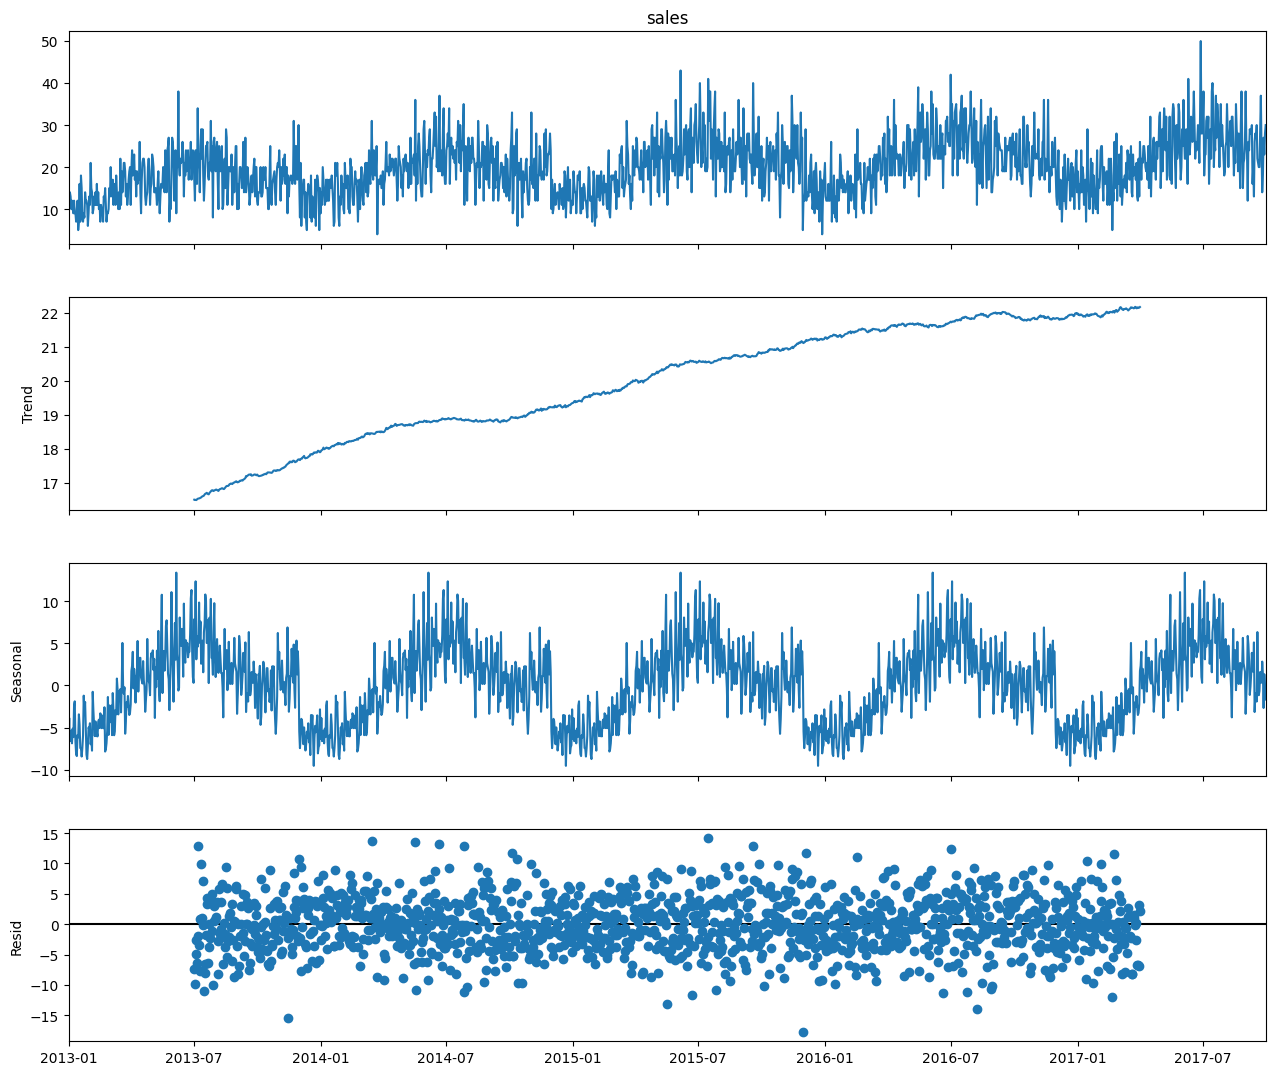

In [ ]:
result = seasonal_decompose(ts_decomp_df['sales'], model='additive', period=365)
fig = result.plot()
fig.set_size_inches(14, 12)
plt.show()

###Determine Error, Trend, and Seasonality
An ETS model has three main components: error, trend, and seasonality. Each can be applied either additively (A), multiplicatively (M), or not at all (N). We will use the Time Series Decomposition Plot to determine the appropriate property for these three components.

Trend - If the trend plot is roughly linear, we apply it additively (A). If the trend line grows or shrinks exponentially, we apply it multiplicatively (M). If there is no clear trend, no trend component is included (N).

Seasonal - If the peaks and valleys for seasonality remain constant over time regardless of the trend, we apply it additively (A). If the size of the seasonal fluctuations tends to increase or decrease proportionally with the level of the time series, we apply it multiplicatively (M). If there is no seasonality, it is not applied (N).

Error - If the error plot has a constant variance over time (the spread of the residuals is about the same size from start to finish), we apply it additively (A). If the variance of the errors fluctuates or fans out as the trend increases, we apply it multiplicatively (M).

For our sales data, we observe a relatively linear upward trend, so we will apply the trend additively (A). However, as the overall sales volume increases, the height of the seasonal fluctuations also grows proportionally, which means we will apply seasonality multiplicatively (M). Because the variance of the data grows alongside the trend, we will apply the error multiplicatively (M) as well. This results in an MAM (Multiplicative Error, Additive Trend, Multiplicative Seasonality) framework.

We will use Exponential Smoothing (specifically Holt-Winters), a commonly-used local statistical algorithm for time-series forecasting. The Exponential Smoothing method can be defined in terms of this ETS framework, allowing us to explicitly define how the smoothing technique should calculate the additive and multiplicative components.

### What is Exponential Smoothing?

This is a very popular scheme to produce a smoothed Time Series. Whereas in Single Moving Averages the past observations are weighted equally, <b>Exponential Smoothing assigns exponentially decreasing weights as the observation get older</b>. In other words, recent observations are given relatively more weight in forecasting than the older observations. <br>
In the case of moving averages, the weights assigned to the observations are the same and are equal to 1/N. In exponential smoothing, however, there are one or more smoothing parameters to be determined (or estimated) and these choices determine the weights assigned to the observations. <br>


There are 3 kinds of smoothing techniques Single, Double and Triple Exponential Smoothing.
1. <b>Single Exponential Smoothing</b> is used when the time series does not have a trend line and a seasonality component.
2. <b>Double Exponential Smoothing</b> is used to include forecasting data with a trend, smoothing calculation includes one for the level, and one for the trend.
3. <b>Triple Exponential smoothing</b> is used when data has trend and seasonality. We include a third equation to take care of seasonality (sometimes called periodicity). The resulting set of equations is called the "Holt-Winters" (HW) method after the names of the inventors.

Since out data has both trend and seasonality components, we will apply Triple Exponential Smoothing.

### 2. Holt Winter's Triple Exponential Smoothing Model
Use this link to get a better understanding of the math behind Triple Exponential Smoothing: https://www.itl.nist.gov/div898/handbook/pmc/section4/pmc435.htm

In [ ]:
hw_train_df = train_df[['date', 'sales']].set_index('date')
hw_test_df = test_df[['date', 'sales']].set_index('date')

# Apply Triple Exponential Smoothing

# Model 1: Additive Trend, Multiplicative Seasonality, 7-Day Period
hw_model_1 = ExponentialSmoothing(
    hw_train_df['sales'],
    trend='add',
    seasonal='mul',
    seasonal_periods=7,
    initialization_method='estimated'  # <-- Moved to model initialization
)
hw_fit_1 = hw_model_1.fit()            # <-- .fit() now runs cleanly
pred_fit_1 = pd.Series(
    hw_fit_1.predict(start=hw_test_df.index[0], end=hw_test_df.index[-1]),
    name='pred_sales'
).reset_index().rename(columns={'index': 'date'})

# Model 2: Damped Additive Trend, Multiplicative Seasonality, 7-Day Period
hw_model_2 = ExponentialSmoothing(
    hw_train_df['sales'],
    trend='add',
    seasonal='mul',
    seasonal_periods=7,
    damped_trend=True,
    initialization_method='estimated'  # <-- Moved to model initialization
)
hw_fit_2 = hw_model_2.fit()            # <-- .fit() now runs cleanly
pred_fit_2 = pd.Series(
    hw_fit_2.predict(start=hw_test_df.index[0], end=hw_test_df.index[-1]),
    name='pred_sales'
).reset_index().rename(columns={'index': 'date'})

print('Forecasts made, ready for evaluation')

Forecasts made, ready for evaluation


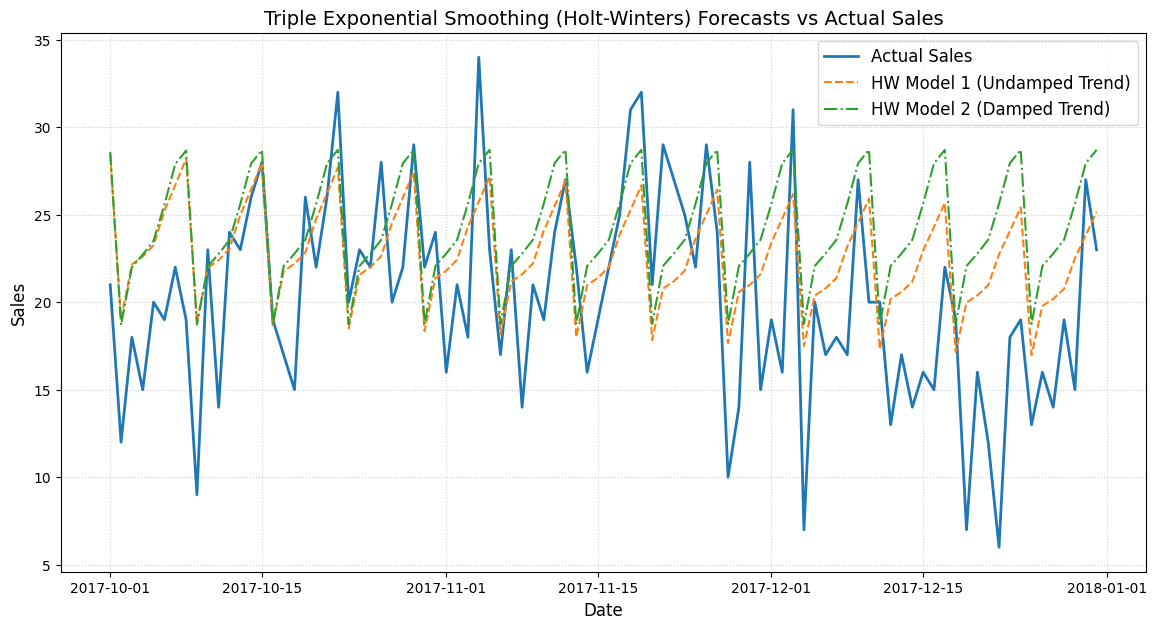

In [ ]:
# Plotting both Holt-Winters forecasts against the actual sales
plt.figure(figsize=(14, 7))

# Actual Sales
plt.plot(test_df['date'], test_df['sales'], label='Actual Sales', color='tab:blue', linewidth=2)

# Model 1: Regular Trend
plt.plot(pred_fit_1['date'], pred_fit_1['pred_sales'],
         label='HW Model 1 (Undamped Trend)', color='tab:orange', linestyle='--')

# Model 2: Damped Trend
plt.plot(pred_fit_2['date'], pred_fit_2['pred_sales'],
         label='HW Model 2 (Damped Trend)', color='tab:green', linestyle='-.')

# Formatting the plot
plt.legend(loc='best', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Sales', fontsize=12)
plt.title('Triple Exponential Smoothing (Holt-Winters) Forecasts vs Actual Sales', fontsize=14)
plt.grid(True, linestyle=':', alpha=0.6)

# Display the plot
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Helper function to compute and format metrics
def evaluate_model(model_name, actuals, preds):
    mae_val = mean_absolute_error(actuals, preds)
    rmse_val = np.sqrt(mean_squared_error(actuals, preds))
    mape_val = mean_absolute_percentage_error(actuals, preds) * 100

    return pd.DataFrame({
        'model': [model_name],
        'total_sales': [actuals.sum()],
        'total_sn_pred_sales': [preds.sum()],  # Kept column name consistent with your earlier dataframe
        'overall_error': [(actuals - preds).sum()],
        'MAE': [mae_val],
        'RMSE': [rmse_val],
        'MAPE': [mape_val]
    }).set_index('model')

# Evaluate both models
actuals = test_df['sales']
hw1_metrics = evaluate_model('Holt-Winters (Undamped)', actuals, pred_fit_1['pred_sales'])
hw2_metrics = evaluate_model('Holt-Winters (Damped)', actuals, pred_fit_2['pred_sales'])

# Append to your existing result_df
result_df = pd.concat([result_df, hw1_metrics, hw2_metrics])
result_df

,total_sales,total_sn_pred_sales,overall_error,MAE,RMSE,MAPE
model,,,,,,
Seasonal Naive,1861,1851.000000,10.000000,5.391304,6.507521,31.794044
Holt-Winters (Undamped),1861,2084.824348,-223.824348,4.578185,5.511976,30.196300
Holt-Winters (Damped),1861,2230.883456,-369.883456,5.345197,6.510141,35.916092


<b> Inference: </b> The decreasing trend is clearly captured by the Holt-Winters Undamped and damped, and the <b>MAPE 30.19%</b> is better in comparision to our baseline model but the damped version having MAPE **35.91** is worse than the baseline model. Let's try Holt-Winters method with a damped parameter, and see if we can improve the results

### 3. Autoregressive Integrated Moving Average - ARIMA Model

#### Step 1: Check stationarity

Before going any further into our analysis, our series has to be made stationary.

Stationarity is the property of exhibiting constant statistical properties (mean, variance, autocorrelation, etc.). If the mean of a time-series increases over time, then it’s not stationary.

The mean across many time periods is only informative if the expected value is the same across those time periods. If these population parameters can vary, what are we really estimating by taking an average across time?

Stationarity requires that the statistical properties must be the same across time, making the sample average a reasonable way to estimate them.

<b> Methods to Check Stationarity </b>

1. <b>Plotting rolling statistics:</b> Plotting rolling means and variances is a first good way to visually inspect our series. If the rolling statistics exhibit a clear trend (upwards or downwards) and show varying variance (increasing or decreasing amplitude), then you might conclude that the series is very likely not to be stationary.



2. <b>Augmented Dickey-Fuller Test:</b> This test is used to assess whether or not a time-series is stationary. It gives a result called a “test-statistic”, based on which you can say, with different levels (or percentage) of confidence, if the time-series is stationary or not. The <b>test statistic</b> is expected to be negative; therefore, it has to be more <b>negative(less)</b> than the <b>critical value</b> for the <b>hypothesis to be rejected</b> and conclude that <b>series is stationary</b>.



3. <b> ACF and PACF plots: </b> An autocorrelation (ACF) plot represents the autocorrelation of the series with lags of itself. A partial autocorrelation (PACF) plot represents the amount of correlation between a series and a lag of itself that is not explained by correlations at all lower-order lags.
Ideally, we want no correlation between the series and lags of itself. Graphically speaking, we would like all the spikes to fall in the blue region.

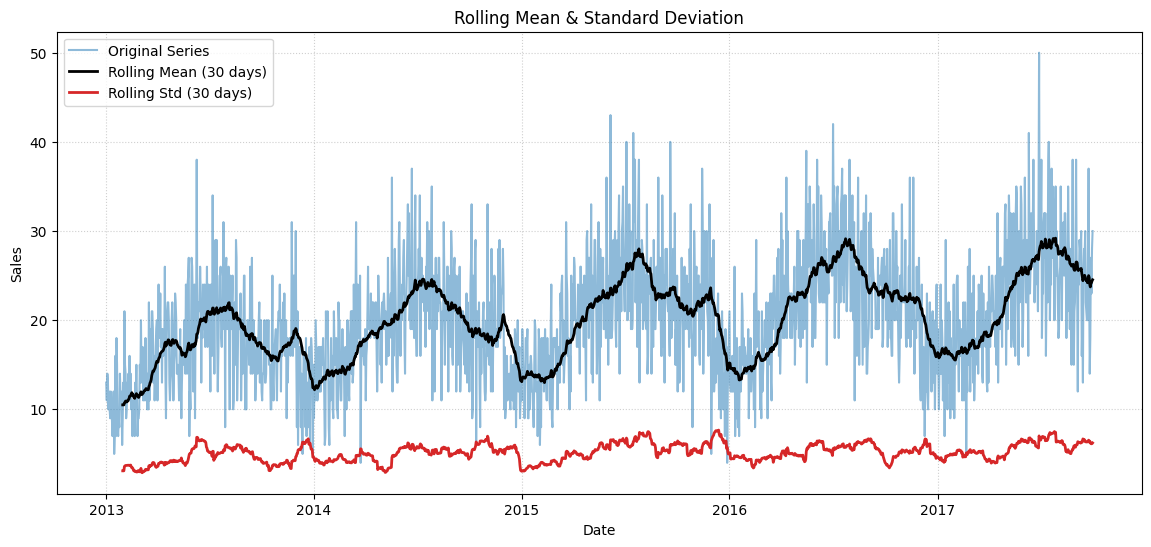

--- Augmented Dickey-Fuller (ADF) Test ---
Test Statistic: -2.9366
P-value: 0.0413
Critical Values:
	1%: -3.4342
	5%: -2.8632
	10%: -2.5677
	1%: -3.434179908502461 - The data is not stationary with 99% confidence
	5%: -2.863231689892687 - The data is  stationary with 95% confidence
	10%: -2.567670609760268 - The data is  stationary with 90% confidence


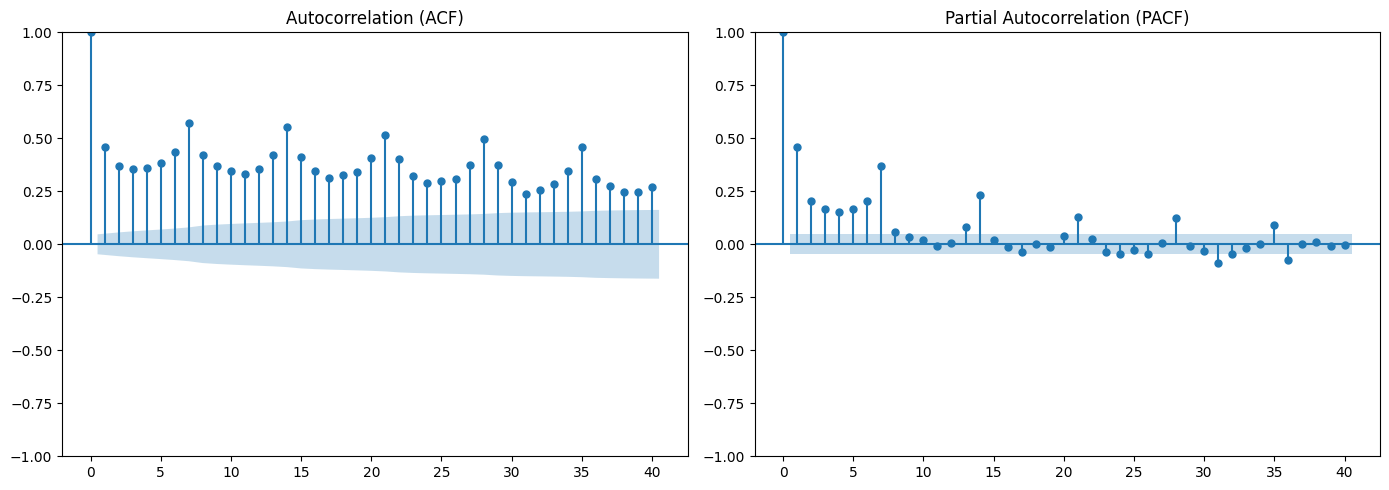

In [ ]:
arima_df = train_df[['date', 'sales']].set_index('date')
arima_test_df = test_df[['date', 'sales']].set_index('date')

def test_stationarity(timeseries, window=30):
    # 1. Plotting rolling statistics
    rollmean = timeseries.rolling(window=window).mean()
    rollstd = timeseries.rolling(window=window).std()

    plt.figure(figsize=(14, 6))
    plt.plot(timeseries, color='tab:blue', alpha=0.5, label='Original Series')
    plt.plot(rollmean, color='black', linewidth=2, label=f'Rolling Mean ({window} days)')
    plt.plot(rollstd, color='tab:red', linewidth=2, label=f'Rolling Std ({window} days)')
    plt.legend(loc='best')
    plt.title('Rolling Mean & Standard Deviation')
    plt.xlabel('Date')
    plt.ylabel('Sales')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.show()

    # 2. Augmented Dickey-Fuller Test
    print("--- Augmented Dickey-Fuller (ADF) Test ---")
    adfuller_test = adfuller(timeseries, autolag='AIC')

    test_statistic = adfuller_test[0]
    p_value = adfuller_test[1]

    print(f"Test Statistic: {test_statistic:.4f}")
    print(f"P-value: {p_value:.4f}")
    print("Critical Values:")
    for key, value in adfuller_test[4].items():
        print(f"\t{key}: {value:.4f}")

    for key, value in adfuller_test[4].items():
        print("\t{}: {} - The data is {} stationary with {}% confidence"
              .format(key, value, '' if adfuller_test[0] < value else 'not', 100-int(key[:-1])))

    # 3. Autocorrelation & Partial Autocorrelation Plots
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))

    # ACF Plot
    plot_acf(timeseries, ax=ax[0], lags=40, color='tab:blue')
    ax[0].set_title('Autocorrelation (ACF)')

    # PACF Plot (method='ywm' suppresses a common statsmodels warning)
    plot_pacf(timeseries, ax=ax[1], lags=40, color='tab:blue', method='ywm')
    ax[1].set_title('Partial Autocorrelation (PACF)')

    plt.tight_layout()
    plt.show()

# Run the test
test_stationarity(arima_df['sales'])

Looking at the results from our test, we can conclude that the series is not stationary for 99% confidence. Therefore, in order to make the series stationary we apply Differencing

#### Step 2: Differencing

<b>Differencing:</b> Seasonal or cyclical patterns can be removed by substracting periodical values. If the data is 12-month seasonal, substracting the series with a 12-lag difference series will give a “flatter” series. Since we have aggregated the data to each day-level, we will shift by 1.

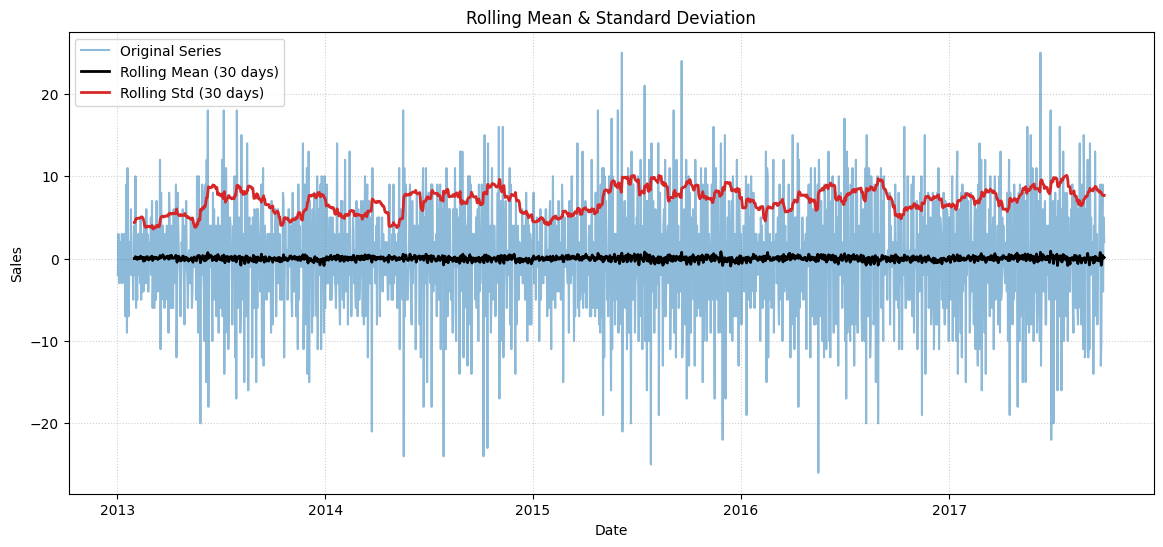

--- Augmented Dickey-Fuller (ADF) Test ---
Test Statistic: -12.3261
P-value: 0.0000
Critical Values:
	1%: -3.4342
	5%: -2.8632
	10%: -2.5677
	1%: -3.434179908502461 - The data is  stationary with 99% confidence
	5%: -2.863231689892687 - The data is  stationary with 95% confidence
	10%: -2.567670609760268 - The data is  stationary with 90% confidence


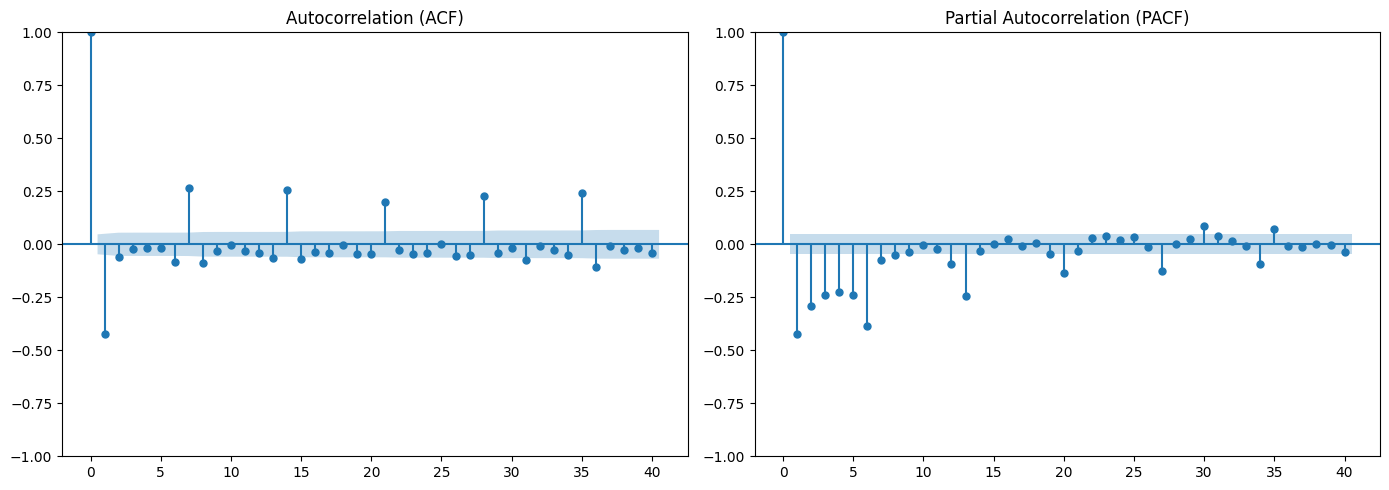

In [ ]:
# Apply first-order differencing using the built-in .diff() method
first_difference = arima_df['sales'].diff().dropna()

# Check for stationarity on the differenced data
test_stationarity(first_difference)

After applying Differencing to the series, we can see from the above results that the series is now stationary, i.e. mean and variance are constant over time, and from ADF we can verify that the test-statistic is lesser than the critical value, hence we can reject the null hypothesis and conclude that the series is staionary.

#Step 3: Model Building
###Interpreting the AR(p), I(d), MA(q), and Seasonal values:
Determining I(d):
Taking the first-order difference makes the time series stationary (the rolling mean is now flattened around zero). Therefore, I(d) = 1.

Determining AR(p):
If the lag-1 autocorrelation of the differenced series PACF is negative, and/or there is a sharp cutoff, then choose an AR order. From the PACF plot, we can clearly observe that the first 6 lags are sequentially negative and significant (crossing the blue confidence interval). Therefore, we will use AR(p) = 6, meaning 6 past days of errors are used to predict the next value.

Determining MA(q):
If the lag-1 autocorrelation of the differenced series ACF is negative, and/or there is a sharp cutoff, then choose an MA order. From the ACF plot, we see a sharp negative spike at lag 1. Therefore, we can use MA(q) = 1.

Determining Seasonal Order (P, D, Q, s):
Looking at the ACF plot, there are highly significant positive spikes at exactly lag 7, 14, 21, 28, and 35. This is the visual signature of a strong 7-day weekly seasonality. Because of this, we cannot use a seasonal_order of (0,0,0,0). We must specify a seasonal period of s = 7 and add seasonal autoregressive (P=1) and moving average (Q=1) terms to capture this repeating weekly pattern.

--- Step 1: Analyzing Seasonality ---


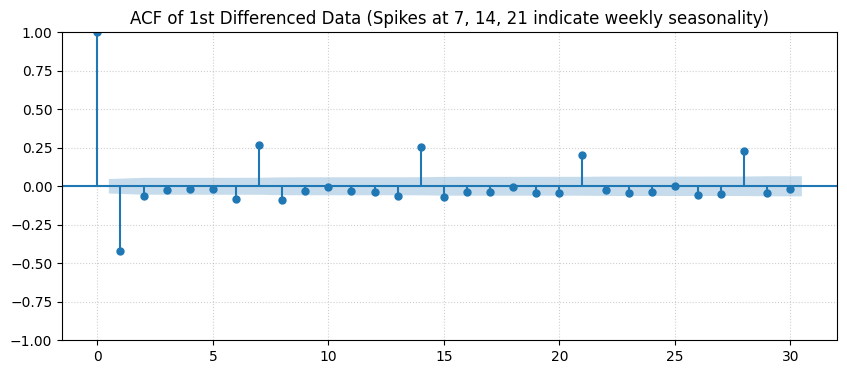


--- Step 2: Fitting SARIMA(6,1,1)(1,1,1,7) ---
                                     SARIMAX Results                                     
Dep. Variable:                             sales   No. Observations:                 1734
Model:             SARIMAX(6, 1, 1)x(1, 1, 1, 7)   Log Likelihood               -5116.793
Date:                           Wed, 12 Aug 2026   AIC                          10253.585
Time:                                   22:26:58   BIC                          10308.121
Sample:                               01-01-2013   HQIC                         10273.759
                                    - 09-30-2017                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0024      0.036     -0.067      0.947      -0.074       0

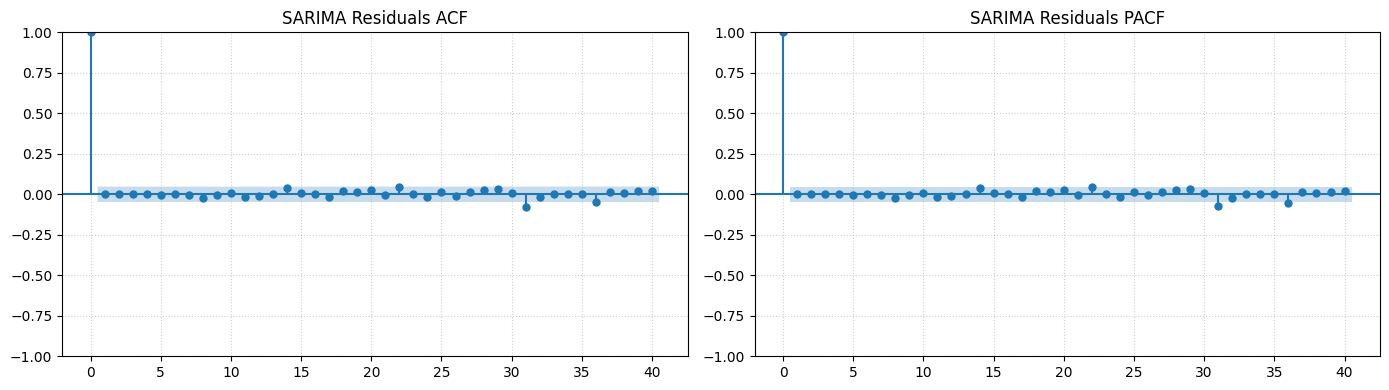

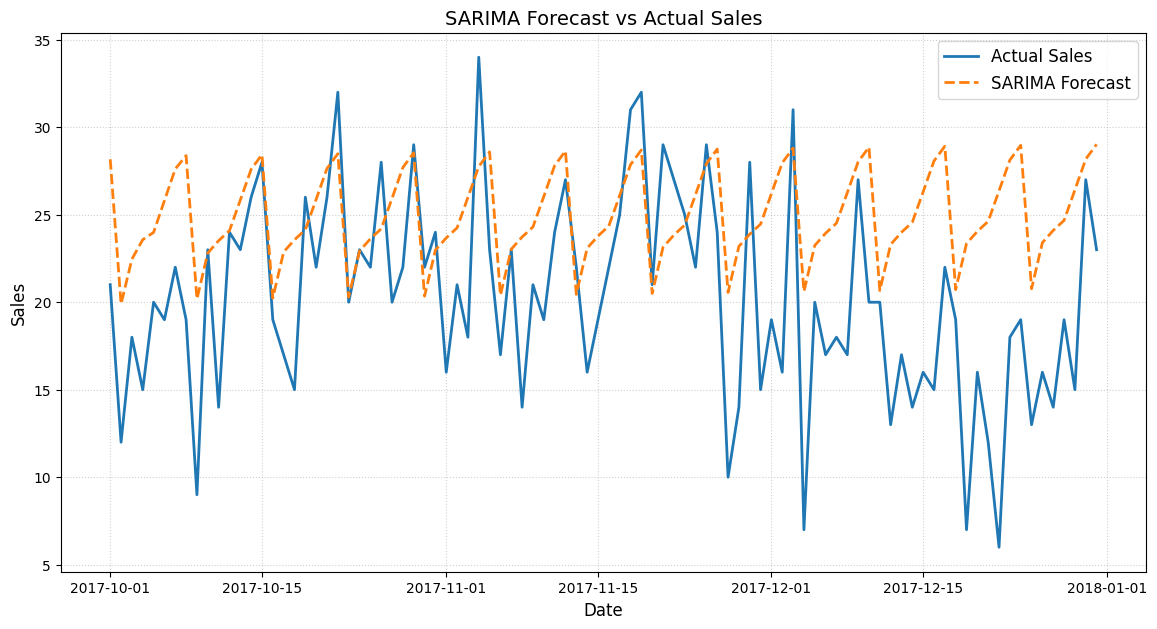

In [ ]:
# =====================================================================
# 1. PRE-ANALYSIS: Check for Seasonality
# =====================================================================
print("--- Step 1: Analyzing Seasonality ---")
# Apply first differencing to remove the trend
first_diff = arima_df['sales'].diff().dropna()

# Plot ACF to look for repeating seasonal spikes
fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(first_diff, lags=30, ax=ax, color='tab:blue')
ax.set_title("ACF of 1st Differenced Data (Spikes at 7, 14, 21 indicate weekly seasonality)")
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# =====================================================================
# 2. FIT FRESH SARIMA MODEL
# =====================================================================
print("\n--- Step 2: Fitting SARIMA(6,1,1)(1,1,1,7) ---")
sarima_model = SARIMAX(
    arima_df['sales'],
    order=(6, 1, 1),
    seasonal_order=(1, 1, 1, 7)
).fit(disp=False)

print(sarima_model.summary())

# =====================================================================
# 3. FORECAST & EVALUATE
# =====================================================================
print("\n--- Step 3: Forecasting and Evaluation ---")
# Generate forecasts
arima_test_df['pred_sales'] = sarima_model.forecast(steps=len(arima_test_df))
arima_test_df['errors'] = arima_test_df['sales'] - arima_test_df['pred_sales']
arima_test_df['model'] = 'SARIMA'

# Calculate standard metrics
mae_val = mean_absolute_error(arima_test_df['sales'], arima_test_df['pred_sales'])
rmse_val = np.sqrt(mean_squared_error(arima_test_df['sales'], arima_test_df['pred_sales']))

# Calculate WMAPE (Weighted MAPE) - Ideal for retail sales data
wmape_val = (np.sum(np.abs(arima_test_df['errors'])) / np.sum(arima_test_df['sales'])) * 100

print(f"MAE:   {mae_val:.4f}")
print(f"RMSE:  {rmse_val:.4f}")
print(f"WMAPE: {wmape_val:.2f}%\n")

# =====================================================================
# 4. RESIDUAL DIAGNOSTICS (ACF & PACF)
# =====================================================================
print("--- Step 4: Residual Diagnostics ---")
# Skip the first 10 residuals to avoid initialization noise from differencing
residuals = sarima_model.resid[10:]

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(residuals, ax=ax[0], lags=40, color='tab:blue')
ax[0].set_title('SARIMA Residuals ACF')
ax[0].grid(True, linestyle=':', alpha=0.6)

plot_pacf(residuals, ax=ax[1], lags=40, color='tab:blue', method='ywm')
ax[1].set_title('SARIMA Residuals PACF')
ax[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# =====================================================================
# 5. VISUALIZE PREDICTIONS VS ACTUALS
# =====================================================================
plt.figure(figsize=(14, 7))
plt.plot(arima_test_df.index, arima_test_df['sales'], label='Actual Sales', color='tab:blue', linewidth=2)
plt.plot(arima_test_df.index, arima_test_df['pred_sales'], label='SARIMA Forecast', color='tab:orange', linestyle='--', linewidth=2)

plt.legend(loc='best', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Sales', fontsize=12)
plt.title('SARIMA Forecast vs Actual Sales', fontsize=14)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

**Inference**: The SARIMA model with MAPE of 28.03% performed better than our baseline model, better the Holt-Winter's Triple Exponential Smoothing method.

--- Step 1: Preparing Exogenous Features ---
Exogenous variables (weekday, month) ready.

--- Step 2: Fitting SARIMAX(6,1,1)(1,1,1,7) with Exog ---
                                     SARIMAX Results                                     
Dep. Variable:                             sales   No. Observations:                 1734
Model:             SARIMAX(6, 1, 1)x(1, 1, 1, 7)   Log Likelihood               -5116.788
Date:                           Wed, 12 Aug 2026   AIC                          10257.575
Time:                                   22:27:23   BIC                          10323.018
Sample:                               01-01-2013   HQIC                         10281.784
                                    - 09-30-2017                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------

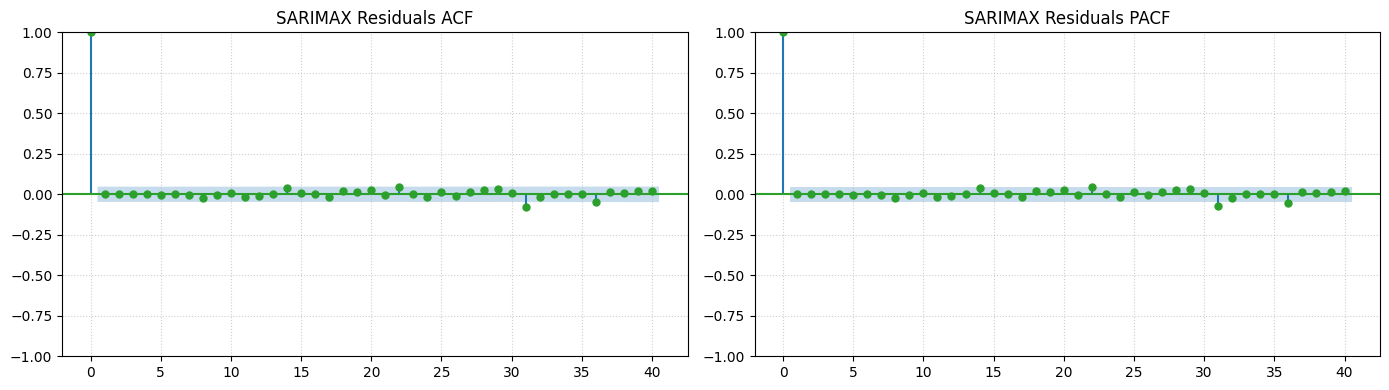

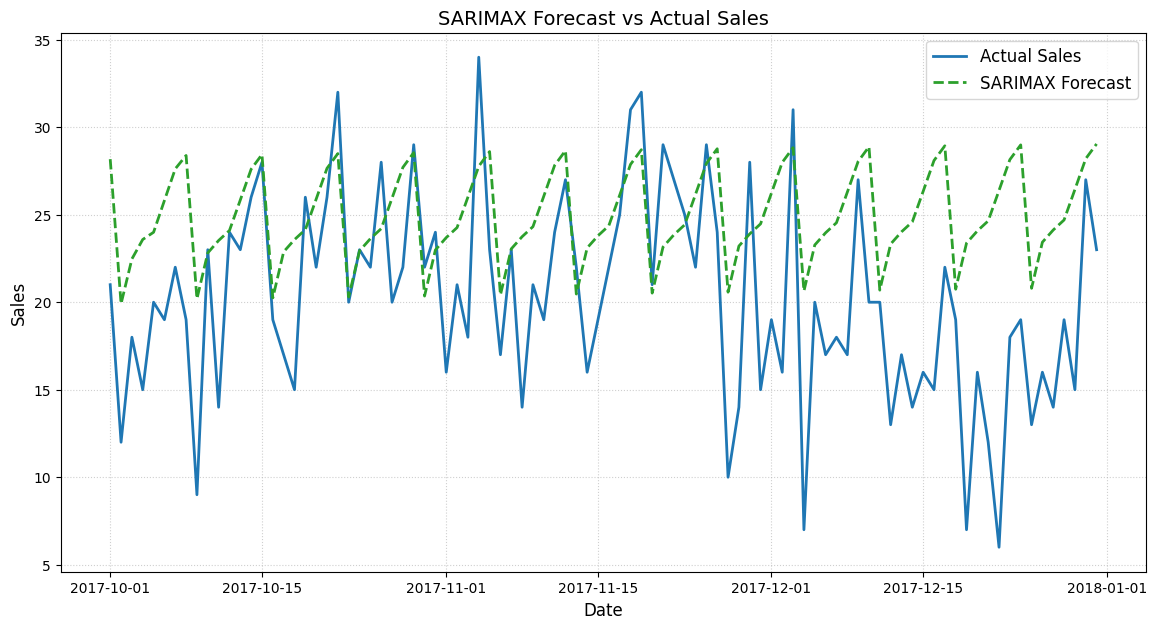

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error

# =====================================================================
# 1. PREPARE EXOGENOUS VARIABLES
# =====================================================================
print("--- Step 1: Preparing Exogenous Features ---")
# Extract weekday and month features for both train and test sets
exog_train = train_df.set_index('date')[['weekday', 'month']]
exog_test = test_df.set_index('date')[['weekday', 'month']]
print("Exogenous variables (weekday, month) ready.")

# =====================================================================
# 2. FIT FRESH SARIMAX MODEL
# =====================================================================
print("\n--- Step 2: Fitting SARIMAX(6,1,1)(1,1,1,7) with Exog ---")
sarimax_model = SARIMAX(
    arima_df['sales'],
    exog=exog_train,
    order=(6, 1, 1),
    seasonal_order=(1, 1, 1, 7)
).fit(disp=False)

print(sarimax_model.summary())

# =====================================================================
# 3. FORECAST & EVALUATE
# =====================================================================
print("\n--- Step 3: Forecasting and Evaluation ---")
# Generate forecasts (Must pass the test exogenous variables here!)
arima_test_df['pred_sales_sarimax'] = sarimax_model.forecast(steps=len(arima_test_df), exog=exog_test)
arima_test_df['errors_sarimax'] = arima_test_df['sales'] - arima_test_df['pred_sales_sarimax']

# Calculate standard metrics
mae_val_x = mean_absolute_error(arima_test_df['sales'], arima_test_df['pred_sales_sarimax'])
rmse_val_x = np.sqrt(mean_squared_error(arima_test_df['sales'], arima_test_df['pred_sales_sarimax']))

# Calculate WMAPE (Weighted MAPE)
wmape_val_x = (np.sum(np.abs(arima_test_df['errors_sarimax'])) / np.sum(arima_test_df['sales'])) * 100

print(f"MAE:   {mae_val_x:.4f}")
print(f"RMSE:  {rmse_val_x:.4f}")
print(f"WMAPE: {wmape_val_x:.2f}%\n")

# =====================================================================
# 4. RESIDUAL DIAGNOSTICS (ACF & PACF)
# =====================================================================
print("--- Step 4: Residual Diagnostics ---")
# Skip the first 10 residuals to avoid initialization noise
residuals_x = sarimax_model.resid[10:]

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(residuals_x, ax=ax[0], lags=40, color='tab:green')
ax[0].set_title('SARIMAX Residuals ACF')
ax[0].grid(True, linestyle=':', alpha=0.6)

plot_pacf(residuals_x, ax=ax[1], lags=40, color='tab:green', method='ywm')
ax[1].set_title('SARIMAX Residuals PACF')
ax[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# =====================================================================
# 5. VISUALIZE PREDICTIONS VS ACTUALS
# =====================================================================
plt.figure(figsize=(14, 7))
plt.plot(arima_test_df.index, arima_test_df['sales'], label='Actual Sales', color='tab:blue', linewidth=2)
plt.plot(arima_test_df.index, arima_test_df['pred_sales_sarimax'], label='SARIMAX Forecast', color='tab:green', linestyle='--', linewidth=2)

plt.legend(loc='best', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Sales', fontsize=12)
plt.title('SARIMAX Forecast vs Actual Sales', fontsize=14)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

**Inference**: The SARIMA model with MAPE of 28.09% performed better than our baseline model, better the Holt-Winter's Triple Exponential Smoothing method.

In [ ]:
from pmdarima import auto_arima

# Auto-SARIMA
sarima = auto_arima(arima_df['sales'], seasonal=True, m=7,
                     max_p=8, max_q=8, max_P=2, max_Q=2,
                     stepwise=True, suppress_warnings=True, error_action='ignore')

arima_test_df['pred_sales'] = sarima.predict(n_periods=len(arima_test_df))
mae = mean_absolute_error(arima_test_df['sales'], arima_test_df['pred_sales'])
rmse = np.sqrt(mean_squared_error(arima_test_df['sales'], arima_test_df['pred_sales']))
wmape = np.sum(np.abs(arima_test_df['sales'] - arima_test_df['pred_sales'])) / np.sum(arima_test_df['sales']) * 100
print(f"SARIMA -> order={sarima.order}, seasonal={sarima.seasonal_order}, MAE={mae:.2f}, RMSE={rmse:.2f}, WMAPE={wmape:.2f}%")

# Residual diagnostics
resid = pd.Series(sarima.resid())[10:]
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(resid, ax=ax[0], lags=40); plot_pacf(resid, ax=ax[1], lags=40, method='ywm')
plt.tight_layout(); plt.show()

# Actual vs forecast
plt.figure(figsize=(14, 6))
plt.plot(arima_test_df.index, arima_test_df['sales'], label='Actual')
plt.plot(arima_test_df.index, arima_test_df['pred_sales'], label='SARIMA Forecast', linestyle='--')
plt.legend(); plt.title('SARIMA Forecast vs Actual'); plt.show()

# Auto-SARIMAX (with exog)
exog_cols = ['is_holiday', 'is_promo', 'macro_indicator']  # replace with your columns
sarimax = auto_arima(arima_df['sales'], exogenous=arima_df[exog_cols], seasonal=True, m=7,
                      max_p=8, max_q=8, max_P=2, max_Q=2,
                      stepwise=True, suppress_warnings=True, error_action='ignore')

arima_test_df['pred_sales_x'] = sarimax.predict(n_periods=len(arima_test_df), exogenous=arima_test_df[exog_cols])
mae_x = mean_absolute_error(arima_test_df['sales'], arima_test_df['pred_sales_x'])
rmse_x = np.sqrt(mean_squared_error(arima_test_df['sales'], arima_test_df['pred_sales_x']))
wmape_x = np.sum(np.abs(arima_test_df['sales'] - arima_test_df['pred_sales_x'])) / np.sum(arima_test_df['sales']) * 100
print(f"SARIMAX -> order={sarimax.order}, seasonal={sarimax.seasonal_order}, MAE={mae_x:.2f}, RMSE={rmse_x:.2f}, WMAPE={wmape_x:.2f}%")

###Transitioning to Deep Learning:
Introduction to LSTMsWhile statistical models like SARIMAX are incredibly powerful and provide great baseline metrics, they rely on rigid mathematical assumptions. They require the data to be strictly stationary (which is why we had to manually apply differencing) and assume that the relationships between past and future sales are linear.To capture more complex, non-linear patterns, we can step into the world of Deep Learning using an LSTM (Long Short-Term Memory) neural network.
###What is an LSTM?
An LSTM is a highly advanced type of Recurrent Neural Network (RNN) specifically designed to process sequential data, like time series, text, or audio. Traditional neural networks process inputs independently, meaning they have no memory of the data that came before. While standard RNNs attempt to fix this by looping past information back into the network, they suffer from a "short-term memory" problem and quickly forget older data.LSTMs solve this by introducing an internal "cell state" and a series of three gates (Forget, Input, and Output). These gates act like filters, allowing the network to mathematically decide which past information is important enough to remember for the long term, and which random noise it should forget.
###Why use an LSTM for our Sales Data?
**No Manual Differencing Required**: Unlike SARIMA, LSTMs do not require the data to be perfectly stationary. The neural network can often learn to navigate upward trends and shifting averages on its own.
**Captures Complex Patterns**: Sales data is rarely perfectly linear. LSTMs can learn complex, hidden relationships between the days that statistical models might miss.
**Automated Feature Extraction**: Instead of manually telling the model that seasonality happens every 7 days (like we did with $s=7$), a well-trained LSTM will independently discover the weekly weekend spikes by recognizing the repeating sequence.
###How the LSTM will work for this dataset
To feed our time-series data into an LSTM, we have to reformat it into a supervised learning problem using a technique called a Sliding Window.Instead of just looking at dates and totals, we will restructure the data into sequences. For example, if we use a 30-day window:
**Step 1**: The model looks at the sequence of Sales from Day 1 to Day 30 to predict Day 31.

**Step 2**: The window "slides" forward one step. The model looks at Day 2 to Day 31 to predict Day 32.

**Step 3**: This continues across the entire dataset.

By training on these overlapping 30-day chunks, the LSTM's internal gates will learn the exact sequence of a typical month—recognizing exactly when the weekend rushes occur within that window and adjusting its next-day prediction accordingly

###Step 1 : Data Preprocessing

In [ ]:
# 1. Extract just the sales values as a 2D numpy array
train_data = train_df['sales'].values.reshape(-1, 1)
test_data = test_df['sales'].values.reshape(-1, 1)

# 2. Scale the data to be between 0 and 1 (Crucial for Neural Networks)
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_train = scaler.fit_transform(train_data)
scaled_test = scaler.transform(test_data)

# 3. Create a helper function to build the sliding window sequences
def create_sequences(data, time_steps=30):
    X, y = [], []
    for i in range(len(data) - time_steps):
        # The past 'time_steps' days
        X.append(data[i:(i + time_steps), 0])
        # The target: the very next day
        y.append(data[i + time_steps, 0])
    return np.array(X), np.array(y)

# We will use the last 30 days of sales to predict the next 1 day
TIME_STEPS = 30

X_train, y_train = create_sequences(scaled_train, TIME_STEPS)
X_test, y_test = create_sequences(scaled_test, TIME_STEPS)

# Reshape X to the 3D format expected by LSTMs: [samples, time_steps, features]
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

print(f"Training Input Shape: {X_train.shape}")
print(f"Testing Input Shape: {X_test.shape}")

Training Input Shape: (1704, 30, 1)
Testing Input Shape: (62, 30, 1)


###Step 2: LSTM Building and Training

In [ ]:
# Build the sequential model
model = Sequential()

# Add an LSTM layer with 70 neurons
model.add(LSTM(units=70, activation='relu', input_shape=(X_train.shape[1], 1)))

# Add Dropout to prevent overfitting (randomly turns off 20% of neurons during training)
model.add(Dropout(0.3))

# Add a Dense output layer (predicting exactly 1 value)
model.add(Dense(units=1))

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# View the model architecture
model.summary()

# Train the model
# (epochs=50 means it passes through the data 50 times; batch_size=32 processes 32 rows at a time)
history = model.fit(
    X_train, y_train,
    epochs=750,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 70)             │        20,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 70)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            71 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,231 (79.03 KB)

 Trainable params: 20,231 (79.03 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/750
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 0.0349 - val_loss: 0.0163
Epoch 2/750
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0172 - val_loss: 0.0157
Epoch 3/750
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0169 - val_loss: 0.0159
Epoch 4/750
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0167 - val_loss: 0.0157
Epoch 5/750
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0160 - val_loss: 0.0156
Epoch 6/750
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0161 - val_loss: 0.0158
Epoch 7/750
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0158 - val_loss: 0.0158
Epoch 8/750
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0159 - val_loss: 0.0161
Epoch 9/750
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0160 - val_loss: 0.0156
Epoch 10/750
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0157 - val_loss: 0.0160
Epoch 11/750
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0159 - val_loss: 0.0164
Epoch 12/750
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step

###Step 3: Evaluation

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step
LSTM MAE:   4.2581
LSTM RMSE:  5.3525
LSTM WMAPE: 21.55%



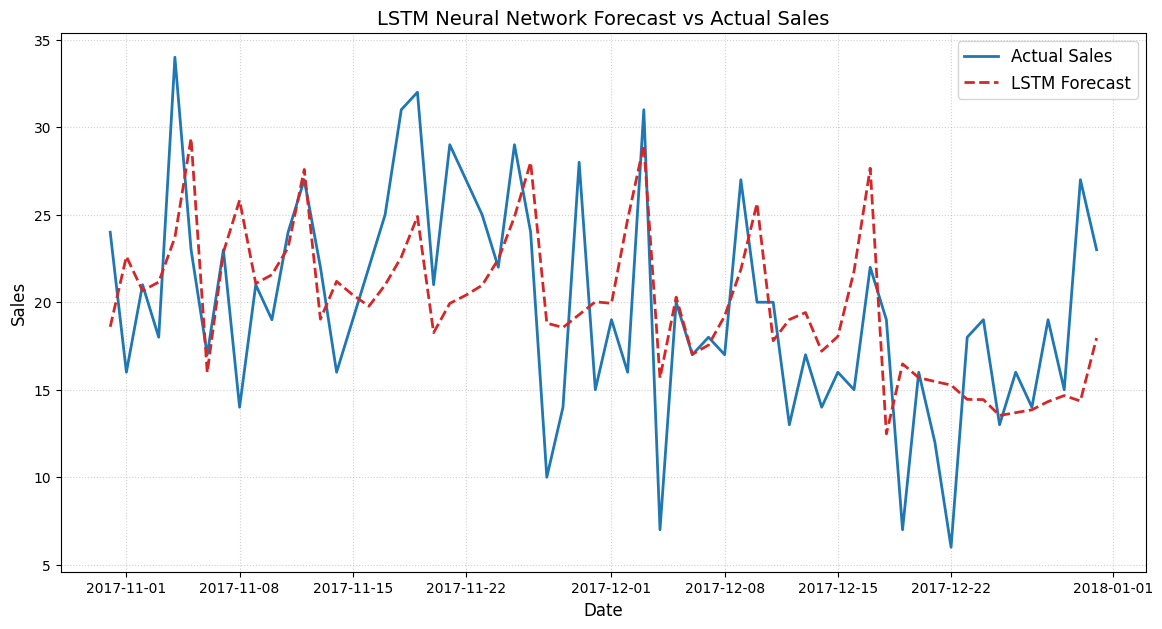

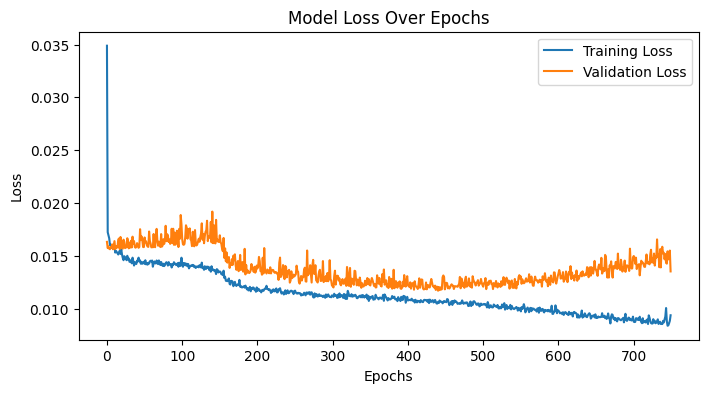

In [ ]:
scaled_predictions = model.predict(X_test)

# 2. Inverse transform the predictions and actuals back to real sales numbers
predictions = scaler.inverse_transform(scaled_predictions)
actuals = scaler.inverse_transform(y_test.reshape(-1, 1))

# 3. Calculate standard metrics
mae_lstm = mean_absolute_error(actuals, predictions)
rmse_lstm = np.sqrt(mean_squared_error(actuals, predictions))
wmape_lstm = (np.sum(np.abs(actuals - predictions)) / np.sum(actuals)) * 100

print(f"LSTM MAE:   {mae_lstm:.4f}")
print(f"LSTM RMSE:  {rmse_lstm:.4f}")
print(f"LSTM WMAPE: {wmape_lstm:.2f}%\n")

# 4. Plotting the results
# Note: Because we used a time step of 30, we lose the first 30 days of the test set in the plot
plot_dates = test_df['date'].iloc[TIME_STEPS:].reset_index(drop=True)

plt.figure(figsize=(14, 7))
plt.plot(plot_dates, actuals, label='Actual Sales', color='tab:blue', linewidth=2)
plt.plot(plot_dates, predictions, label='LSTM Forecast', color='tab:red', linestyle='--', linewidth=2)

plt.legend(loc='best', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Sales', fontsize=12)
plt.title('LSTM Neural Network Forecast vs Actual Sales', fontsize=14)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# 5. Plot the training loss to ensure the model actually learned
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

**Inference**: The Mape is reduced to **21.55%**, better than all of the above models.

### Supervised Machine Learning: Linear Regression

Let's apply Linear Regression to our time series data in order to forecasts sales.

###Step 1
Feature Engineering (Lags and Rolling Windows)Why we do this: Standard Machine Learning models do not understand the concept of "time" or sequence. To fix this, we convert the time-series data into a standard supervised learning problem. We create Lag features (what were the sales $x$ days ago?) and Rolling Window features (what was the average/max/min over the last week?) to give the model historical context for every single day.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.linear_model import LinearRegression

# Create a copy to avoid altering the original dataframe
reg_df = train_df[['date', 'sales']].copy() # Assuming you have a base dataframe

# 1. Create Lag features (1 to 7 days prior)
for i in range(1, 8):
    lag_i = f'lag_{i}'
    reg_df[lag_i] = reg_df['sales'].shift(i)

# 2. Create Rolling window features (7-day window)
reg_df['rolling_mean'] = reg_df['sales'].rolling(window=7).mean()
reg_df['rolling_max'] = reg_df['sales'].rolling(window=7).max()
reg_df['rolling_min'] = reg_df['sales'].rolling(window=7).min()

# 3. Clean up the dataset
# Drop rows with NaN values created by the shifts and rolling windows (the first 7 days)
reg_df = reg_df.dropna(how='any').reset_index(drop=True)

###Step 2: Strict Chronological Train/Test Split
Why we do this: In time-series forecasting, we can never use random splitting (like train_test_split). We must strictly split the data chronologically to ensure no "future" data leaks into the training set. We will use data up to September 2017 for training, and the last 3 months of 2017 for testing

In [ ]:
# 1. Ensure dates are sorted chronologically
if reg_df.index.name == 'date':
    reg_df = reg_df.reset_index()
reg_df['date'] = pd.to_datetime(reg_df['date'])
reg_df = reg_df.sort_values('date').set_index('date')

# 2. Foolproof split: Mathematically slice the exact length of your original test set from the end
test_length = len(test_df)

reg_train_df = reg_df.iloc[:-test_length]  # Everything EXCEPT the last 'test_length' rows
reg_test_df = reg_df.iloc[-test_length:]   # ONLY the last 'test_length' rows

# 3. Separate features (X) and target (y)
X_train = reg_train_df.drop(['sales'], axis=1)
y_train = reg_train_df['sales'].values

X_test = reg_test_df.drop(['sales'], axis=1)
y_test = reg_test_df['sales'].values

# 4. Diagnostic check
print(f"Train Shape: {X_train.shape}")
print(f"Test Shape: {X_test.shape}")

Train Shape: (1635, 10)
Test Shape: (92, 10)


###Step 3: Feature Selection and EDA
Why we do this: Feeding too many highly correlated features into a Linear Regression model causes multicollinearity, which degrades performance. We use a correlation heatmap and SelectKBest to identify the absolute strongest predictors of sales, ensuring our model stays fast and accurate.

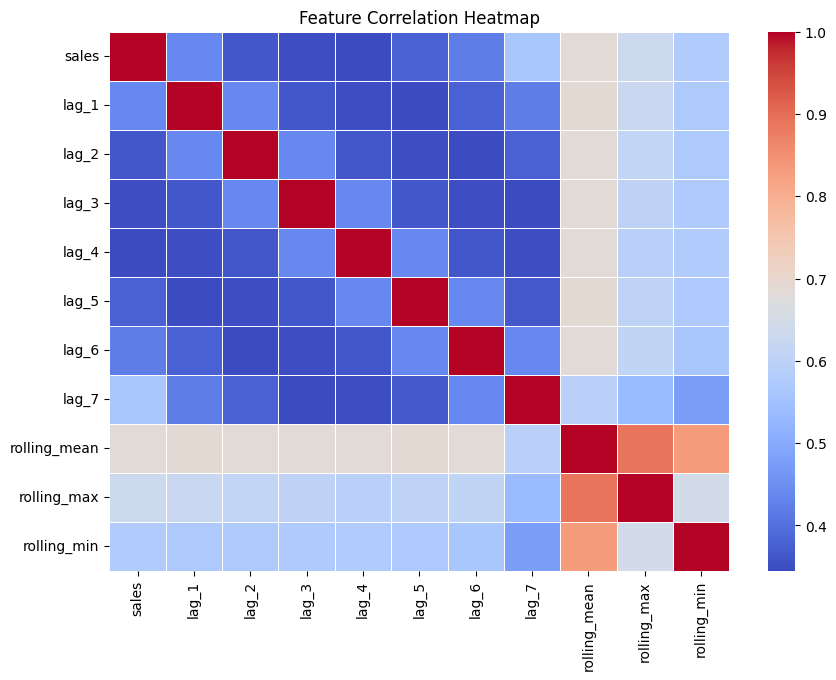

Top 5 Best Features:
        Feature        Score
7  rolling_mean  1447.791633
8   rolling_max  1081.284932
9   rolling_min   815.095602
6         lag_7   752.577518
0         lag_1   390.390637


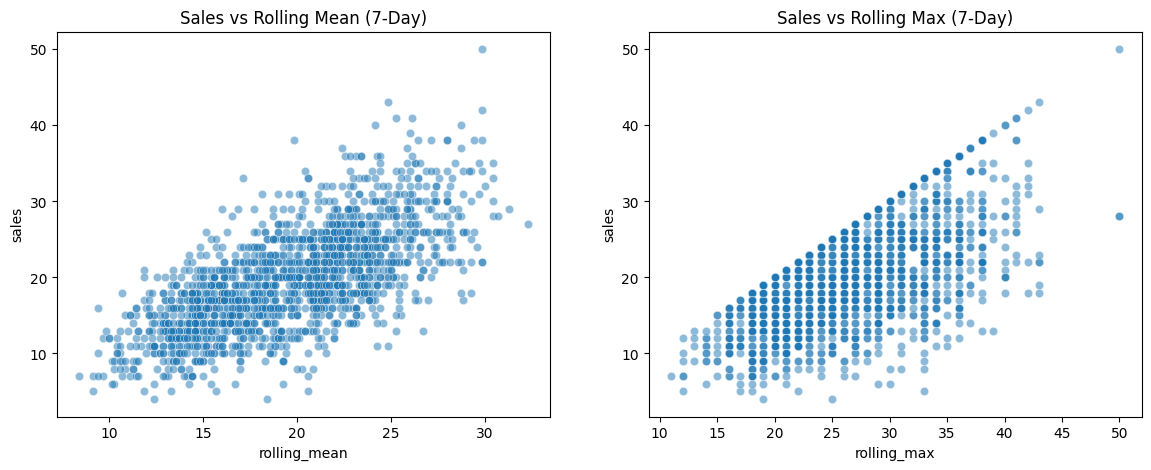

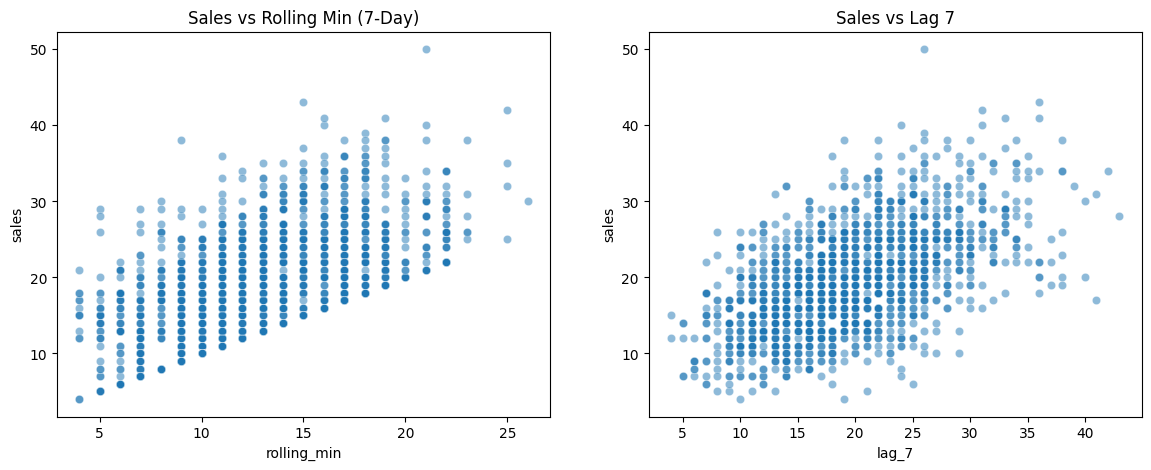

In [ ]:
# 1. Correlation matrix with heatmap
corr = reg_train_df.corr()
plt.figure(figsize=(10, 7))
sns.heatmap(corr, linewidths=.5, cmap='coolwarm', annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()

# 2. Univariate SelectKBest class to extract top 5 best features
top_features = SelectKBest(score_func=f_regression, k=5)
fit = top_features.fit(X_train, y_train)

# Combine scores and column names for visualization
feature_scores = pd.DataFrame({
    'Feature': X_train.columns,
    'Score': fit.scores_
})

print("Top 5 Best Features:")
print(feature_scores.nlargest(5, 'Score'))

# 3. Checking for a linear relationship of the top features with sales
fig, axs = plt.subplots(ncols=2, figsize=(14, 5))
sns.scatterplot(x=reg_train_df['rolling_mean'], y=reg_train_df['sales'], ax=axs[0], alpha=0.5)
axs[0].set(title='Sales vs Rolling Mean (7-Day)')

sns.scatterplot(x=reg_train_df['rolling_max'], y=reg_train_df['sales'], ax=axs[1], alpha=0.5)
axs[1].set(title='Sales vs Rolling Max (7-Day)')
plt.show()

fig, axs = plt.subplots(ncols=2, figsize=(14, 5))
sns.scatterplot(x=reg_train_df['rolling_min'], y=reg_train_df['sales'], ax=axs[0], alpha=0.5)
axs[0].set(title='Sales vs Rolling Min (7-Day)')

sns.scatterplot(x=reg_train_df['lag_7'], y=reg_train_df['sales'], ax=axs[1], alpha=0.5)
axs[1].set(title='Sales vs Lag 7')
plt.show()

###Step 4: Model Training
Why we do this: Now that we have identified the most impactful features (the rolling metrics and the 7-day lags), we filter our training data to only include these columns. We then fit a standard Linear Regression model to find the optimal weights for these historical patterns.

In [ ]:
# Extract the best features identified in the previous step
selected_features = ['rolling_mean', 'rolling_max', 'rolling_min', 'lag_7', 'lag_1']

# Re-define X_train and X_test using ONLY the selected features
X_train_final = reg_train_df[selected_features].values
X_test_final = reg_test_df[selected_features].values

# Fit the Linear Regression model
model = LinearRegression()
model.fit(X_train_final, y_train)

# Generate Predictions
preds = model.predict(X_test_final)

###Step 5: Evaluation and Visualization
Why we do this: Metrics like MAE and RMSE tell us the average error, but plotting the actuals vs. predictions and the absolute errors allows us to visually inspect where the model is failing (e.g., is it consistently under-predicting on weekends?).

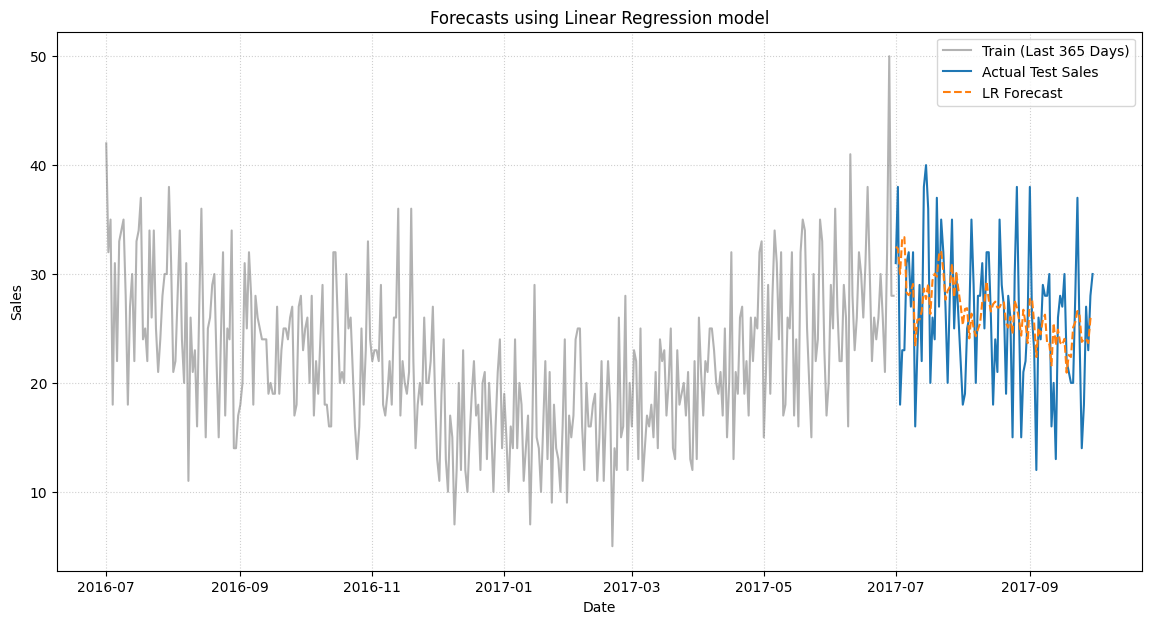

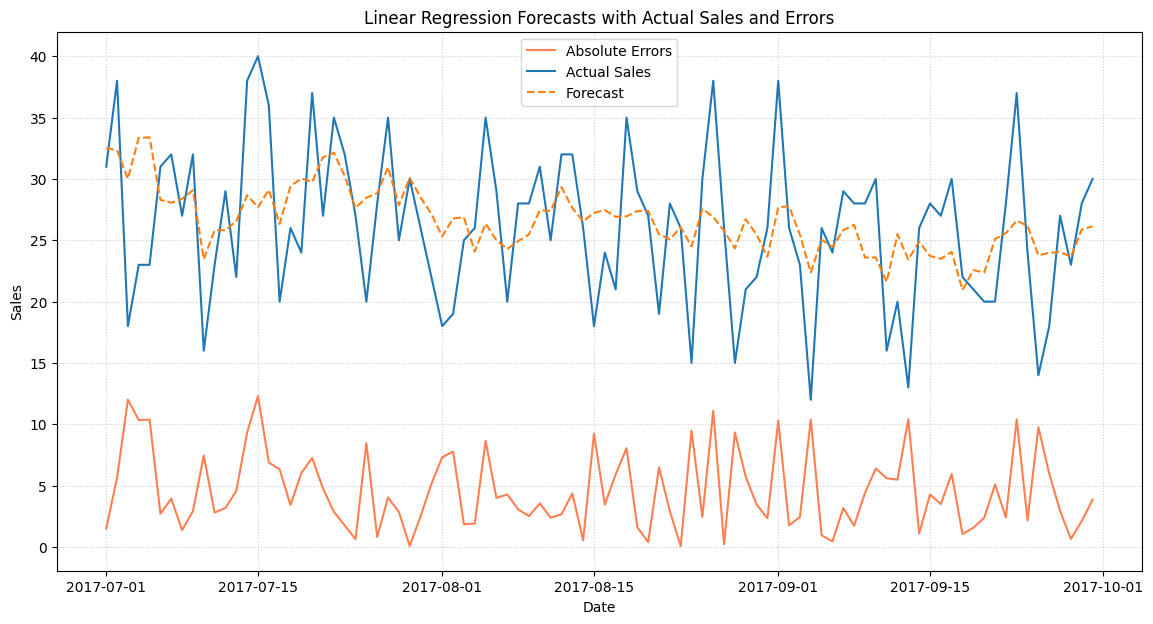

,total_sales,total_pred_sales,LR_overall_error,MAE,RMSE,MAPE
model,,,,,,
LinearRegression,2403,2449.530457,46.530457,4.570029,5.5744,17.496574


In [ ]:
# Define metric helper functions for the groupby aggregation
def mae(err): return np.mean(np.abs(err))
def rmse(err): return np.sqrt(np.mean(err ** 2))
def mape(err):
    # Safely fetch actuals to calculate percentage error
    actuals = reg_test_df.loc[err.index, 'sales']
    return (np.sum(np.abs(err)) / np.sum(actuals)) * 100

# Reconstruct errors_df safely
errors_df = reg_test_df[['sales']].copy()
errors_df['pred_sales'] = preds
errors_df['errors'] = preds - y_test
errors_df['model'] = 'LinearRegression'

# Plot 1: Train, Test, and Forecast Context
plt.figure(figsize=(14, 7))
# Plot only the last 365 days of train so the forecast is clearly visible
train_subset = reg_train_df.last('365D')
plt.plot(train_subset.index, train_subset['sales'], label='Train (Last 365 Days)', color='gray', alpha=0.6)
plt.plot(reg_test_df.index, reg_test_df['sales'], label='Actual Test Sales', color='tab:blue')
plt.plot(errors_df.index, errors_df['pred_sales'], label='LR Forecast', color='tab:orange', linestyle='--')
plt.legend(loc='best')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.title('Forecasts using Linear Regression model')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# Plot 2: Zoomed in Forecast vs Actuals and Error Margins
plt.figure(figsize=(14, 7))
plt.plot(errors_df.index, np.abs(errors_df['errors']), label='Absolute Errors', color='coral')
plt.plot(errors_df.index, errors_df['sales'], label='Actual Sales', color='tab:blue')
plt.plot(errors_df.index, errors_df['pred_sales'], label='Forecast', color='tab:orange', linestyle='--')
plt.legend(loc='best')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.title('Linear Regression Forecasts with Actual Sales and Errors')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# Generate Results DataFrame
result_df_lr = errors_df.groupby('model').agg(
    total_sales=('sales', 'sum'),
    total_pred_sales=('pred_sales', 'sum'),
    LR_overall_error=('errors', 'sum'),
    MAE=('errors', mae),
    RMSE=('errors', rmse),
    MAPE=('errors', mape)
)

display(result_df_lr)

Inference: The Mape is reduced to 17.49%, that is better every sequential model above.

###Step 6: XGBoost Model Training
Why we do this: We are using the exact same historical features (rolling_mean, rolling_max, rolling_min, lag_7, lag_1) but applying a more advanced gradient boosting algorithm. XGBoost builds hundreds of small decision trees, each one trying to correct the errors made by the previous tree, which typically results in a highly accurate forecast.

In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV

# 1. We use the same optimal features identified during the feature selection phase
selected_features = ['rolling_mean', 'rolling_max', 'rolling_min', 'lag_7', 'lag_1']

X_train_final = reg_train_df[selected_features].values
X_test_final = reg_test_df[selected_features].values

# (y_train and y_test are already defined from your previous split)

# 2. Define the hyperparameter grid to search
param_grid = {
    'n_estimators': [100, 300, 500, 700],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7, 9],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}

# 3. Initialize the base XGBoost model
xgb_base = XGBRegressor(random_state=42, objective='reg:squarederror')

# 4. Set up RandomizedSearchCV
# n_iter=20 means it will test 20 random combinations from the grid above
# scoring='neg_mean_absolute_error' forces the search to optimize for your MAE metric
print("Starting Hyperparameter Tuning for XGBoost (this may take a minute)...")
xgb_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid,
    n_iter=20,
    scoring='neg_mean_absolute_error',
    cv=3,               # 3-fold cross validation
    verbose=1,
    random_state=42,
    n_jobs=-1           # Uses all available CPU cores to speed up training
)

# 5. Fit the search to find the optimal model
xgb_search.fit(X_train_final, y_train)

# Extract the mathematically best model from the search
xgb_model_optimized = xgb_search.best_estimator_

print("\n--- Optimal Parameters Found ---")
for key, value in xgb_search.best_params_.items():
    print(f"{key}: {value}")

# 6. Generate Predictions using the mathematically optimized model
xgb_preds = xgb_model_optimized.predict(X_test_final)
print("\nOptimized XGBoost training and prediction complete.")

Starting Hyperparameter Tuning for XGBoost (this may take a minute)...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

--- Optimal Parameters Found ---
subsample: 0.8
n_estimators: 700
max_depth: 3
learning_rate: 0.01
colsample_bytree: 0.9

Optimized XGBoost training and prediction complete.


###Step 7: XGBoost Evaluation and Visualization
Why we do this: We need to evaluate the XGBoost predictions using the exact same metrics (MAE, RMSE, MAPE) and visual plots as the Linear Regression model to see if the complex tree-based approach actually improved our accuracy.


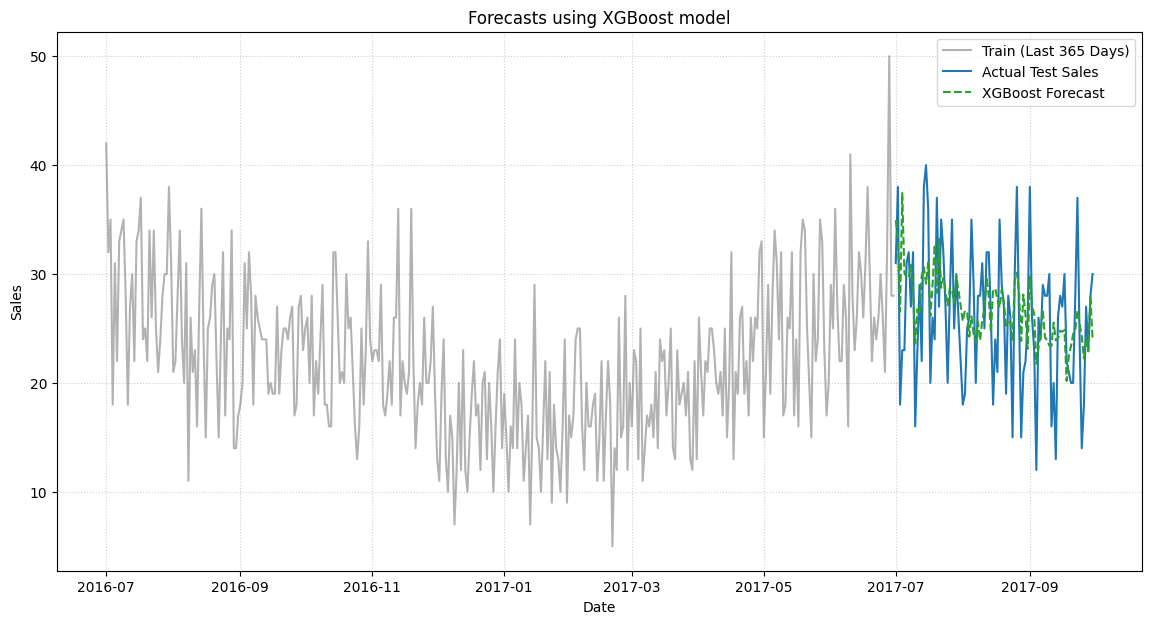

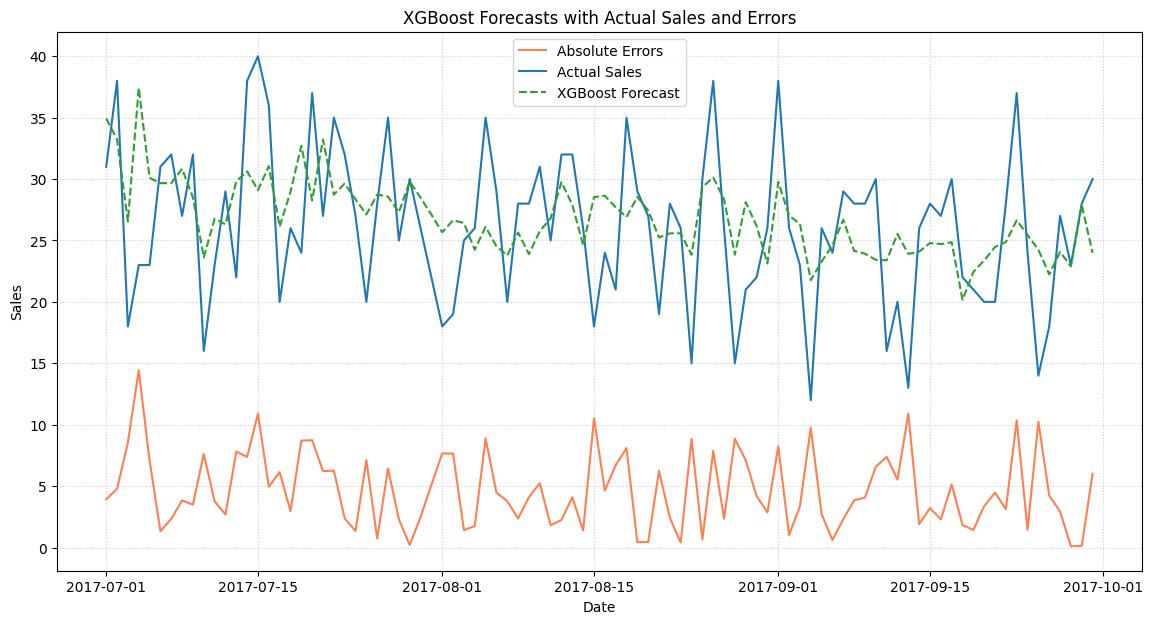

,total_sales,total_pred_sales,XGB_overall_error,MAE,RMSE,MAPE
model,,,,,,
XGBoost,2403,2465.196533,62.196598,4.67584,5.609241,17.901676


In [ ]:
# Reconstruct an errors dataframe specifically for XGBoost
xgb_errors_df = reg_test_df[['sales']].copy()
xgb_errors_df['pred_sales'] = xgb_preds
xgb_errors_df['errors'] = xgb_preds - y_test
xgb_errors_df['model'] = 'XGBoost'

# Plot 1: Train, Test, and Forecast Context
plt.figure(figsize=(14, 7))
# Plot only the last 365 days of train so the forecast is clearly visible
train_subset = reg_train_df.last('365D')
plt.plot(train_subset.index, train_subset['sales'], label='Train (Last 365 Days)', color='gray', alpha=0.6)
plt.plot(reg_test_df.index, reg_test_df['sales'], label='Actual Test Sales', color='tab:blue')
plt.plot(xgb_errors_df.index, xgb_errors_df['pred_sales'], label='XGBoost Forecast', color='tab:green', linestyle='--')
plt.legend(loc='best')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.title('Forecasts using XGBoost model')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# Plot 2: Zoomed in Forecast vs Actuals and Error Margins
plt.figure(figsize=(14, 7))
plt.plot(xgb_errors_df.index, np.abs(xgb_errors_df['errors']), label='Absolute Errors', color='coral')
plt.plot(xgb_errors_df.index, xgb_errors_df['sales'], label='Actual Sales', color='tab:blue')
plt.plot(xgb_errors_df.index, xgb_errors_df['pred_sales'], label='XGBoost Forecast', color='tab:green', linestyle='--')
plt.legend(loc='best')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.title('XGBoost Forecasts with Actual Sales and Errors')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# Generate Results DataFrame using your existing metric functions (mae, rmse, mape)
result_df_xgb = xgb_errors_df.groupby('model').agg(
    total_sales=('sales', 'sum'),
    total_pred_sales=('pred_sales', 'sum'),
    XGB_overall_error=('errors', 'sum'),
    MAE=('errors', mae),
    RMSE=('errors', rmse),
    MAPE=('errors', mape)
)

# Display the XGBoost metrics
display(result_df_xgb)

Inference: This is not less than that of linear regression

###Conclusion
This analysis demonstrates that while Deep Learning (LSTM) excels at raw sequential pattern recognition and absolute error reduction, carefully engineered historical features fed into gradient-boosted trees can provide superior stability and percentage-based accuracy. Combining robust feature engineering with hyperparameter optimization remains a highly competitive approach for commercial sales forecasting.